# Blended Score Matrix Analysis

This notebook evaluates whether a historical rugby league score matrix improves the probability distribution produced by independent Poisson scores.

It keeps two evaluation layers separate:

1. **Expected-score quality**
   - Home-score MAE
   - Away-score MAE
   - Margin MAE
   - Total-points MAE

2. **Distribution quality**
   - Exact-score negative log loss
   - Match-result log loss and Brier score
   - Handicap log loss
   - Totals log loss
   - Calibration
   - Preservation of the supplied expected home and away scores

## Models compared

- Pure independent Poisson
- Exponentially tilted historical matrix
- Convex blends between the Poisson and tilted historical matrices

The historical matrix is rebuilt using only matches before each evaluated fixture, preventing future leakage.

## 1. Imports and configuration

Update `DATABASE_PATH` and, if necessary, the SQL query in the next section to match the project schema.

In [2]:
from __future__ import annotations

import math
import sqlite3
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATABASE_PATH = Path("../data/rugby_league_pricing.db")

# Maximum score represented on each axis.
MAX_SCORE = 80

# Chronological evaluation period.
# Leave as None to use the final 25% of dates as the test period.
TEST_START_DATE: str | None = None

# Minimum number of prior matches required to build an empirical matrix.
MIN_HISTORY_MATCHES = 100

# Historical weighting:
# 0-2 years old => 1.0
# 2-4 years old => 0.5
# Older results decay progressively.
RECENT_YEARS = 2.0
MID_YEARS = 4.0
MID_WEIGHT = 0.5
OLDER_HALF_LIFE_YEARS = 2.0

# Candidate historical blend weights.
BLEND_WEIGHTS = np.round(np.arange(0.0, 0.95, 0.05), 2)

EPSILON = 1e-12

## 2. Load historical expected scores and actual results

The query must return one row per completed fixture with these fields:

- `fixture_id`
- `match_date`
- `home_team`
- `away_team`
- `actual_home_score`
- `actual_away_score`
- `expected_home_score`
- `expected_away_score`

Edit only this query if your exact column names differ.

In [1]:
QUERY = '''
SELECT
    f.fixture_id,
    f.match_date,
    ht.canonical_name AS home_team,
    at.canonical_name AS away_team,
    r.home_score AS actual_home_score,
    r.away_score AS actual_away_score,
    es.expected_home_score,
    es.expected_away_score
FROM fixtures AS f
JOIN teams AS ht
    ON ht.team_id = f.home_team_id
JOIN teams AS at
    ON at.team_id = f.away_team_id
JOIN results AS r
    ON r.fixture_id = f.fixture_id
JOIN expected_scores AS es
    ON es.fixture_id = f.fixture_id
ORDER BY f.match_date, f.fixture_id
'''

if not DATABASE_PATH.exists():
    raise FileNotFoundError(
        f"Database not found at {DATABASE_PATH.resolve()}. "
        "Update DATABASE_PATH before continuing."
    )

with sqlite3.connect(DATABASE_PATH) as connection:
    matches = pd.read_sql_query(QUERY, connection)

matches["match_date"] = pd.to_datetime(matches["match_date"])

numeric_columns = [
    "actual_home_score",
    "actual_away_score",
    "expected_home_score",
    "expected_away_score",
]
matches[numeric_columns] = matches[numeric_columns].apply(pd.to_numeric, errors="coerce")
matches = matches.dropna(subset=["match_date", *numeric_columns]).copy()
matches = matches.sort_values(["match_date", "fixture_id"]).reset_index(drop=True)

assert not matches.empty, "The query returned no completed fixtures."
assert (matches[numeric_columns] >= 0).all().all(), "Scores and expected scores must be non-negative."

matches.head()

NameError: name 'DATABASE_PATH' is not defined

In [30]:
print(f"Rows: {len(matches):,}")
print(f"Date range: {matches['match_date'].min().date()} to {matches['match_date'].max().date()}")
print(matches[numeric_columns].describe().round(3))

Rows: 3,103
Date range: 2010-01-30 to 2026-07-26
       actual_home_score  actual_away_score  expected_home_score  \
count           3103.000           3103.000             3103.000   
mean              24.689             20.898               25.774   
std               13.932             12.674                5.313   
min                0.000              0.000                6.000   
25%               14.000             12.000               21.900   
50%               22.000             19.000               25.248   
75%               34.000             28.000               29.116   
max               84.000             84.000               45.933   

       expected_away_score  
count             3103.000  
mean                22.110  
std                  4.568  
min                 11.157  
25%                 18.851  
50%                 21.759  
75%                 24.909  
max                 39.489  


## 3. Baseline expected-score accuracy

These metrics evaluate the upstream ratings and expected-score model. They do **not** determine whether the full score distribution is realistic.

In [31]:
def mean_absolute_error(actual: pd.Series, predicted: pd.Series) -> float:
    return float(np.mean(np.abs(actual.to_numpy() - predicted.to_numpy())))


baseline_score_metrics = pd.Series(
    {
        "home_score_mae": mean_absolute_error(
            matches["actual_home_score"], matches["expected_home_score"]
        ),
        "away_score_mae": mean_absolute_error(
            matches["actual_away_score"], matches["expected_away_score"]
        ),
        "margin_mae": mean_absolute_error(
            matches["actual_home_score"] - matches["actual_away_score"],
            matches["expected_home_score"] - matches["expected_away_score"],
        ),
        "total_points_mae": mean_absolute_error(
            matches["actual_home_score"] + matches["actual_away_score"],
            matches["expected_home_score"] + matches["expected_away_score"],
        ),
    },
    name="value",
)

baseline_score_metrics.round(4)

home_score_mae      10.4121
away_score_mae       9.2934
margin_mae          15.7132
total_points_mae    12.0340
Name: value, dtype: float64

## 4. Score-matrix functions

The historical matrix is **exponentially tilted** so that its implied home and away means match the fixture-specific expected scores.

This retains empirical rugby league structure—variance, score correlation, tails, and common score combinations—without allowing the league-wide historical mean to replace the fixture prediction.

In [32]:
def poisson_probabilities(mean: float, max_score: int = MAX_SCORE) -> np.ndarray:
    if mean < 0:
        raise ValueError("Poisson mean must be non-negative.")

    probabilities = np.empty(max_score + 1, dtype=float)
    probabilities[0] = math.exp(-mean)

    for score in range(1, max_score + 1):
        probabilities[score] = probabilities[score - 1] * mean / score

    # Scores beyond max_score are folded into the final bucket.
    tail = max(0.0, 1.0 - probabilities.sum())
    probabilities[-1] += tail
    probabilities /= probabilities.sum()
    return probabilities


def poisson_score_matrix(
    expected_home: float,
    expected_away: float,
    max_score: int = MAX_SCORE,
) -> np.ndarray:
    home = poisson_probabilities(expected_home, max_score)
    away = poisson_probabilities(expected_away, max_score)
    matrix = np.outer(home, away)
    return matrix / matrix.sum()


def matrix_means(matrix: np.ndarray) -> tuple[float, float]:
    scores = np.arange(matrix.shape[0], dtype=float)
    home_mean = float((matrix * scores[:, None]).sum())
    away_mean = float((matrix * scores[None, :]).sum())
    return home_mean, away_mean

In [33]:
def historical_weight(
    match_date: pd.Timestamp,
    as_of_date: pd.Timestamp,
) -> float:
    age_years = max(0.0, (as_of_date - match_date).days / 365.25)

    if age_years <= RECENT_YEARS:
        return 1.0
    if age_years <= MID_YEARS:
        return MID_WEIGHT

    extra_years = age_years - MID_YEARS
    return MID_WEIGHT * 0.5 ** (extra_years / OLDER_HALF_LIFE_YEARS)


def build_historical_matrix(
    prior_matches: pd.DataFrame,
    as_of_date: pd.Timestamp,
    max_score: int = MAX_SCORE,
    smoothing: float = 1e-6,
) -> np.ndarray:
    matrix = np.full((max_score + 1, max_score + 1), smoothing, dtype=float)

    for row in prior_matches.itertuples(index=False):
        home_score = min(int(row.actual_home_score), max_score)
        away_score = min(int(row.actual_away_score), max_score)
        weight = historical_weight(pd.Timestamp(row.match_date), as_of_date)
        matrix[home_score, away_score] += weight

    return matrix / matrix.sum()

In [34]:
def tilt_matrix_to_means(
    base_matrix: np.ndarray,
    target_home_mean: float,
    target_away_mean: float,
    tolerance: float = 1e-8,
    max_iterations: int = 100,
) -> np.ndarray:
    """Exponentially tilt a joint matrix to specified marginal means.

    q(i, j) is proportional to:
        base(i, j) * exp(alpha * i + beta * j)

    Newton updates use the covariance matrix of home and away scores.
    """
    if base_matrix.ndim != 2 or base_matrix.shape[0] != base_matrix.shape[1]:
        raise ValueError("base_matrix must be a square 2D matrix.")

    base = np.asarray(base_matrix, dtype=float)
    if np.any(base < 0) or base.sum() <= 0:
        raise ValueError("base_matrix must contain non-negative probability mass.")

    base = np.maximum(base / base.sum(), EPSILON)
    scores = np.arange(base.shape[0], dtype=float)
    home_grid = scores[:, None]
    away_grid = scores[None, :]

    alpha = 0.0
    beta = 0.0

    for _ in range(max_iterations):
        log_weights = np.log(base) + alpha * home_grid + beta * away_grid
        log_weights -= np.max(log_weights)
        tilted = np.exp(log_weights)
        tilted /= tilted.sum()

        home_mean = float((tilted * home_grid).sum())
        away_mean = float((tilted * away_grid).sum())
        error = np.array(
            [home_mean - target_home_mean, away_mean - target_away_mean],
            dtype=float,
        )

        if np.max(np.abs(error)) < tolerance:
            return tilted

        home_var = float((tilted * (home_grid - home_mean) ** 2).sum())
        away_var = float((tilted * (away_grid - away_mean) ** 2).sum())
        covariance = float(
            (tilted * (home_grid - home_mean) * (away_grid - away_mean)).sum()
        )

        hessian = np.array(
            [[home_var, covariance], [covariance, away_var]],
            dtype=float,
        )
        hessian += np.eye(2) * 1e-10

        step = np.linalg.solve(hessian, error)
        alpha -= float(step[0])
        beta -= float(step[1])

    raise RuntimeError(
        "Matrix tilting did not converge. Increase MAX_SCORE or inspect target means."
    )


def blend_matrices(
    poisson_matrix: np.ndarray,
    historical_matrix: np.ndarray,
    historical_weight_value: float,
) -> np.ndarray:
    if not 0.0 <= historical_weight_value <= 1.0:
        raise ValueError("historical_weight_value must be between 0 and 1.")

    blended = (
        (1.0 - historical_weight_value) * poisson_matrix
        + historical_weight_value * historical_matrix
    )
    return blended / blended.sum()

## 5. Market aggregation and scoring metrics

In [35]:
def safe_probability(value: float) -> float:
    return float(np.clip(value, EPSILON, 1.0 - EPSILON))


def binary_log_loss(outcome: int, probability: float) -> float:
    probability = safe_probability(probability)
    return float(
        -(outcome * math.log(probability) + (1 - outcome) * math.log(1 - probability))
    )


def match_result_probabilities(matrix: np.ndarray) -> dict[str, float]:
    return {
        "home": float(np.tril(matrix, k=-1).sum()),
        "draw": float(np.trace(matrix)),
        "away": float(np.triu(matrix, k=1).sum()),
    }


def total_over_probability(matrix: np.ndarray, line: float) -> float:
    scores = np.arange(matrix.shape[0])
    total_grid = scores[:, None] + scores[None, :]
    return float(matrix[total_grid > line].sum())


def home_margin_over_probability(matrix: np.ndarray, line: float) -> float:
    scores = np.arange(matrix.shape[0])
    margin_grid = scores[:, None] - scores[None, :]
    return float(matrix[margin_grid > line].sum())


def categorical_log_loss(actual_label: str, probabilities: dict[str, float]) -> float:
    return float(-math.log(safe_probability(probabilities[actual_label])))


def categorical_brier(actual_label: str, probabilities: dict[str, float]) -> float:
    labels = ("home", "draw", "away")
    return float(
        sum(
            (probabilities[label] - float(label == actual_label)) ** 2
            for label in labels
        )
    )


def actual_result_label(home_score: float, away_score: float) -> str:
    if home_score > away_score:
        return "home"
    if home_score < away_score:
        return "away"
    return "draw"

## 6. Choose a chronological test period

No random split is used. Every evaluated fixture is priced using only earlier results.

In [36]:
if TEST_START_DATE is None:
    unique_dates = np.sort(matches["match_date"].dt.normalize().unique())
    split_index = int(len(unique_dates) * 0.75)
    test_start = pd.Timestamp(unique_dates[split_index])
else:
    test_start = pd.Timestamp(TEST_START_DATE)

evaluation_matches = matches.loc[matches["match_date"] >= test_start].copy()

print(f"Test starts: {test_start.date()}")
print(f"Evaluation fixtures: {len(evaluation_matches):,}")

Test starts: 2022-07-17
Evaluation fixtures: 738


## 7. Run the rolling backtest

For each fixture:

1. Build the empirical matrix from earlier matches only.
2. Generate the independent Poisson matrix.
3. Tilt the empirical matrix to the same expected home and away means.
4. Test every blend weight.
5. Score the actual result and central handicap/total events.

The central lines are defined as:

- total line: `floor(expected total) + 0.5`
- home-margin line: `floor(expected home margin) + 0.5`

This avoids pushes and gives a consistent probability test even without bookmaker closing lines.

In [37]:
@dataclass(frozen=True)
class EvaluationRecord:
    fixture_id: int | str
    match_date: pd.Timestamp
    model: str
    historical_weight: float
    exact_score_log_loss: float
    result_log_loss: float
    result_brier: float
    handicap_log_loss: float
    totals_log_loss: float
    implied_home_mean_error: float
    implied_away_mean_error: float


records: list[EvaluationRecord] = []
skipped = 0

for row in evaluation_matches.itertuples(index=False):
    prior = matches.loc[matches["match_date"] < row.match_date]

    if len(prior) < MIN_HISTORY_MATCHES:
        skipped += 1
        continue

    expected_home = float(row.expected_home_score)
    expected_away = float(row.expected_away_score)
    actual_home = int(row.actual_home_score)
    actual_away = int(row.actual_away_score)

    poisson_matrix = poisson_score_matrix(expected_home, expected_away)
    empirical_matrix = build_historical_matrix(prior, pd.Timestamp(row.match_date))
    tilted_empirical = tilt_matrix_to_means(
        empirical_matrix,
        target_home_mean=expected_home,
        target_away_mean=expected_away,
    )

    total_line = math.floor(expected_home + expected_away) + 0.5
    margin_line = math.floor(expected_home - expected_away) + 0.5

    actual_result = actual_result_label(actual_home, actual_away)
    actual_total_over = int(actual_home + actual_away > total_line)
    actual_margin_over = int(actual_home - actual_away > margin_line)

    for weight in BLEND_WEIGHTS:
        matrix = blend_matrices(poisson_matrix, tilted_empirical, float(weight))
        model_name = "pure_poisson" if weight == 0 else f"blend_{weight:.2f}"

        score_home_index = min(actual_home, MAX_SCORE)
        score_away_index = min(actual_away, MAX_SCORE)
        exact_probability = safe_probability(
            float(matrix[score_home_index, score_away_index])
        )

        result_probabilities = match_result_probabilities(matrix)
        total_probability = total_over_probability(matrix, total_line)
        margin_probability = home_margin_over_probability(matrix, margin_line)
        implied_home, implied_away = matrix_means(matrix)

        records.append(
            EvaluationRecord(
                fixture_id=row.fixture_id,
                match_date=pd.Timestamp(row.match_date),
                model=model_name,
                historical_weight=float(weight),
                exact_score_log_loss=-math.log(exact_probability),
                result_log_loss=categorical_log_loss(
                    actual_result, result_probabilities
                ),
                result_brier=categorical_brier(actual_result, result_probabilities),
                handicap_log_loss=binary_log_loss(
                    actual_margin_over, margin_probability
                ),
                totals_log_loss=binary_log_loss(
                    actual_total_over, total_probability
                ),
                implied_home_mean_error=implied_home - expected_home,
                implied_away_mean_error=implied_away - expected_away,
            )
        )

backtest = pd.DataFrame(records)

if backtest.empty:
    raise RuntimeError(
        "No fixtures were evaluated. Lower MIN_HISTORY_MATCHES or move TEST_START_DATE."
    )

print(f"Skipped for insufficient history: {skipped:,}")
print(f"Evaluation records: {len(backtest):,}")
backtest.sample(5).T

Skipped for insufficient history: 0
Evaluation records: 14,022


,3897,1409,6756,3339,180
fixture_id,2023-09-01_5_3,2023-03-10_2_9,2024-07-27_10_6,2023-07-16_10_2,2022-07-29_15_4
match_date,2023-09-01 00:00:00,2023-03-10 00:00:00,2024-07-27 00:00:00,2023-07-16 00:00:00,2022-07-29 00:00:00
model,blend_0.10,blend_0.15,blend_0.55,blend_0.70,blend_0.45
historical_weight,0.1,0.15,0.55,0.7,0.45
exact_score_log_loss,6.275347,7.430979,6.316406,6.36533,7.602442
result_log_loss,1.170248,0.803169,0.640421,0.287715,2.14357
result_brier,0.890481,0.557973,0.419103,0.120114,1.543322
handicap_log_loss,0.662361,0.694158,0.640421,0.685378,0.700879
totals_log_loss,0.714306,0.719165,0.748345,0.646154,0.717854
implied_home_mean_error,-0.0,0.0,0.0,-0.0,0.0


## 8. Compare model performance

Lower is better for every loss column. Mean errors should remain approximately zero.

In [38]:
summary = (
    backtest.groupby(["historical_weight", "model"], as_index=False)
    .agg(
        fixtures=("fixture_id", "nunique"),
        exact_score_log_loss=("exact_score_log_loss", "mean"),
        result_log_loss=("result_log_loss", "mean"),
        result_brier=("result_brier", "mean"),
        handicap_log_loss=("handicap_log_loss", "mean"),
        totals_log_loss=("totals_log_loss", "mean"),
        home_mean_abs_error=("implied_home_mean_error", lambda s: np.mean(np.abs(s))),
        away_mean_abs_error=("implied_away_mean_error", lambda s: np.mean(np.abs(s))),
    )
    .sort_values("historical_weight")
)

summary.round(6)

,historical_weight,model,fixtures,exact_score_log_loss,result_log_loss,result_brier,handicap_log_loss,totals_log_loss,home_mean_abs_error,away_mean_abs_error
0,0.00,pure_poisson,738,12.037936,0.793254,0.437075,0.691652,0.689403,0.0,0.0
1,0.05,blend_0.05,738,8.787158,0.728309,0.431940,0.691670,0.689006,0.0,0.0
2,0.10,blend_0.10,738,8.414684,0.700171,0.427203,0.691693,0.688613,0.0,0.0
3,0.15,blend_0.15,738,8.184792,0.680323,0.422864,0.691720,0.688224,0.0,0.0
4,0.20,blend_0.20,738,8.017411,0.665121,0.418923,0.691752,0.687840,0.0,0.0
5,0.25,blend_0.25,738,7.885851,0.653031,0.415381,0.691789,0.687460,0.0,0.0
6,0.30,blend_0.30,738,7.777766,0.643225,0.412236,0.691830,0.687085,0.0,0.0
7,0.35,blend_0.35,738,7.686400,0.635199,0.409489,0.691876,0.686715,0.0,0.0
8,0.40,blend_0.40,738,7.607652,0.628615,0.407141,0.691927,0.686349,0.0,0.0
9,0.45,blend_0.45,738,7.538859,0.623240,0.405190,0.691982,0.685987,0.0,0.0


## 9. Visualise blend-weight sensitivity

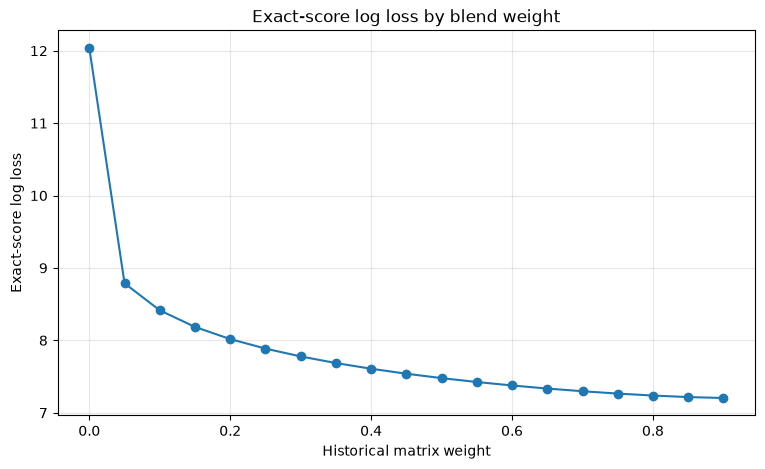

In [40]:
plt.figure(figsize=(9, 5))
plt.plot(
    summary["historical_weight"],
    summary["exact_score_log_loss"],
    marker="o",
)
plt.xlabel("Historical matrix weight")
plt.ylabel("Exact-score log loss")
plt.title("Exact-score log loss by blend weight")
plt.grid(alpha=0.3)
plt.show()

In [43]:
additional_weights = [0.95, 1.00]
additional_records = []

for row in evaluation_matches.itertuples(index=False):
    prior = matches.loc[matches["match_date"] < row.match_date]

    if len(prior) < MIN_HISTORY_MATCHES:
        continue

    expected_home = float(row.expected_home_score)
    expected_away = float(row.expected_away_score)
    actual_home = int(row.actual_home_score)
    actual_away = int(row.actual_away_score)

    poisson_matrix = poisson_score_matrix(
        expected_home,
        expected_away,
    )

    empirical_matrix = build_historical_matrix(
        prior,
        pd.Timestamp(row.match_date),
    )

    tilted_empirical = tilt_matrix_to_means(
        empirical_matrix,
        target_home_mean=expected_home,
        target_away_mean=expected_away,
    )

    total_line = math.floor(expected_home + expected_away) + 0.5
    margin_line = math.floor(expected_home - expected_away) + 0.5

    actual_result = actual_result_label(
        actual_home,
        actual_away,
    )

    actual_total_over = int(
        actual_home + actual_away > total_line
    )

    actual_margin_over = int(
        actual_home - actual_away > margin_line
    )

    for weight in additional_weights:
        matrix = blend_matrices(
            poisson_matrix,
            tilted_empirical,
            historical_weight_value=weight,
        )

        score_home_index = min(actual_home, MAX_SCORE)
        score_away_index = min(actual_away, MAX_SCORE)

        exact_probability = safe_probability(
            float(matrix[score_home_index, score_away_index])
        )

        result_probabilities = match_result_probabilities(matrix)

        total_probability = total_over_probability(
            matrix,
            total_line,
        )

        margin_probability = home_margin_over_probability(
            matrix,
            margin_line,
        )

        implied_home, implied_away = matrix_means(matrix)

        additional_records.append(
            {
                "fixture_id": row.fixture_id,
                "match_date": pd.Timestamp(row.match_date),
                "model": (
                    "tilted_historical"
                    if weight == 1.0
                    else f"blend_{weight:.2f}"
                ),
                "historical_weight": weight,
                "exact_score_log_loss": -math.log(exact_probability),
                "result_log_loss": categorical_log_loss(
                    actual_result,
                    result_probabilities,
                ),
                "result_brier": categorical_brier(
                    actual_result,
                    result_probabilities,
                ),
                "handicap_log_loss": binary_log_loss(
                    actual_margin_over,
                    margin_probability,
                ),
                "totals_log_loss": binary_log_loss(
                    actual_total_over,
                    total_probability,
                ),
                "implied_home_mean_error": (
                    implied_home - expected_home
                ),
                "implied_away_mean_error": (
                    implied_away - expected_away
                ),
            }
        )

additional_backtest = pd.DataFrame(additional_records)

backtest_extended = pd.concat(
    [
        backtest.loc[
            ~backtest["historical_weight"].isin(additional_weights)
        ],
        additional_backtest,
    ],
    ignore_index=True,
)

In [44]:
summary_extended = (
    backtest_extended
    .groupby(
        ["historical_weight", "model"],
        as_index=False,
    )
    .agg(
        fixtures=("fixture_id", "nunique"),
        exact_score_log_loss=(
            "exact_score_log_loss",
            "mean",
        ),
        result_log_loss=(
            "result_log_loss",
            "mean",
        ),
        result_brier=(
            "result_brier",
            "mean",
        ),
        handicap_log_loss=(
            "handicap_log_loss",
            "mean",
        ),
        totals_log_loss=(
            "totals_log_loss",
            "mean",
        ),
        home_mean_abs_error=(
            "implied_home_mean_error",
            lambda values: np.mean(np.abs(values)),
        ),
        away_mean_abs_error=(
            "implied_away_mean_error",
            lambda values: np.mean(np.abs(values)),
        ),
    )
    .sort_values("historical_weight")
    .reset_index(drop=True)
)

summary_extended.round(6)

,historical_weight,model,fixtures,exact_score_log_loss,result_log_loss,result_brier,handicap_log_loss,totals_log_loss,home_mean_abs_error,away_mean_abs_error
0,0.00,pure_poisson,738,12.037936,0.793254,0.437075,0.691652,0.689403,0.0,0.0
1,0.05,blend_0.05,738,8.787158,0.728309,0.431940,0.691670,0.689006,0.0,0.0
2,0.10,blend_0.10,738,8.414684,0.700171,0.427203,0.691693,0.688613,0.0,0.0
3,0.15,blend_0.15,738,8.184792,0.680323,0.422864,0.691720,0.688224,0.0,0.0
4,0.20,blend_0.20,738,8.017411,0.665121,0.418923,0.691752,0.687840,0.0,0.0
5,0.25,blend_0.25,738,7.885851,0.653031,0.415381,0.691789,0.687460,0.0,0.0
6,0.30,blend_0.30,738,7.777766,0.643225,0.412236,0.691830,0.687085,0.0,0.0
7,0.35,blend_0.35,738,7.686400,0.635199,0.409489,0.691876,0.686715,0.0,0.0
8,0.40,blend_0.40,738,7.607652,0.628615,0.407141,0.691927,0.686349,0.0,0.0
9,0.45,blend_0.45,738,7.538859,0.623240,0.405190,0.691982,0.685987,0.0,0.0


In [46]:
metrics = [
    "exact_score_log_loss",
    "result_log_loss",
    "result_brier",
    "handicap_log_loss",
    "totals_log_loss",
]

best_rows = []

for metric in metrics:
    best_index = summary_extended[metric].idxmin()
    row = summary_extended.loc[best_index]

    best_rows.append(
        {
            "metric": metric,
            "best_model": row["model"],
            "best_historical_weight": row[
                "historical_weight"
            ],
            "best_score": row[metric],
        }
    )

best_by_metric = pd.DataFrame(best_rows)

best_by_metric.round(6)

,metric,best_model,best_historical_weight,best_score
0,exact_score_log_loss,blend_0.90,0.90,7.203610
1,result_log_loss,blend_0.80,0.80,0.609059
2,result_brier,blend_0.65,0.65,0.401368
3,handicap_log_loss,pure_poisson,0.00,0.691652
4,totals_log_loss,tilted_historical,1.00,0.682307


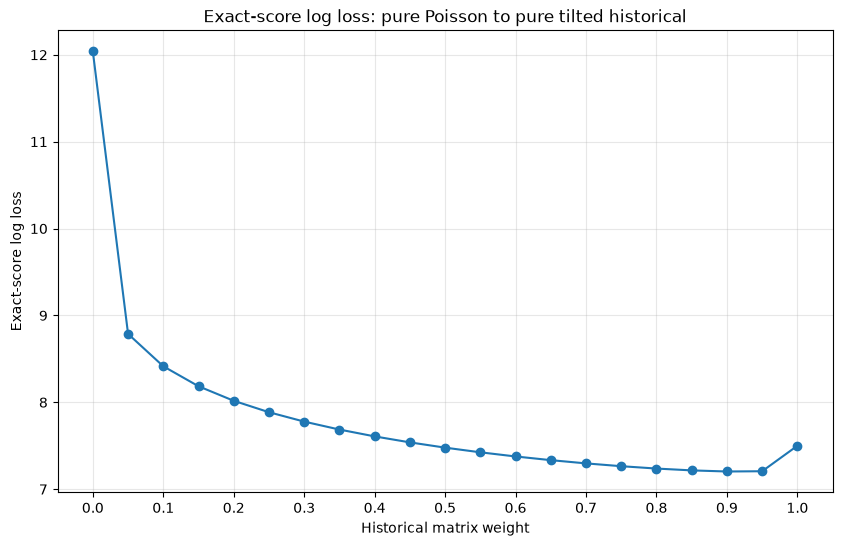

In [47]:
plt.figure(figsize=(10, 6))

plt.plot(
    summary_extended["historical_weight"],
    summary_extended["exact_score_log_loss"],
    marker="o",
)

plt.xlabel("Historical matrix weight")
plt.ylabel("Exact-score log loss")
plt.title(
    "Exact-score log loss: "
    "pure Poisson to pure tilted historical"
)
plt.xticks(np.arange(0.0, 1.01, 0.1))
plt.grid(alpha=0.3)
plt.show()

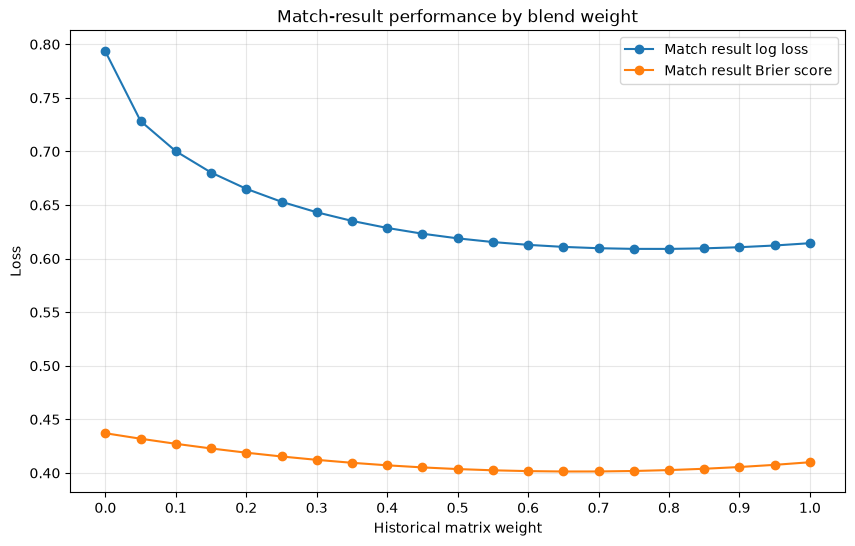

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(
    summary_extended["historical_weight"],
    summary_extended["result_log_loss"],
    marker="o",
    label="Match result log loss",
)

plt.plot(
    summary_extended["historical_weight"],
    summary_extended["result_brier"],
    marker="o",
    label="Match result Brier score",
)

plt.xlabel("Historical matrix weight")
plt.ylabel("Loss")
plt.title("Match-result performance by blend weight")
plt.xticks(np.arange(0.0, 1.01, 0.1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

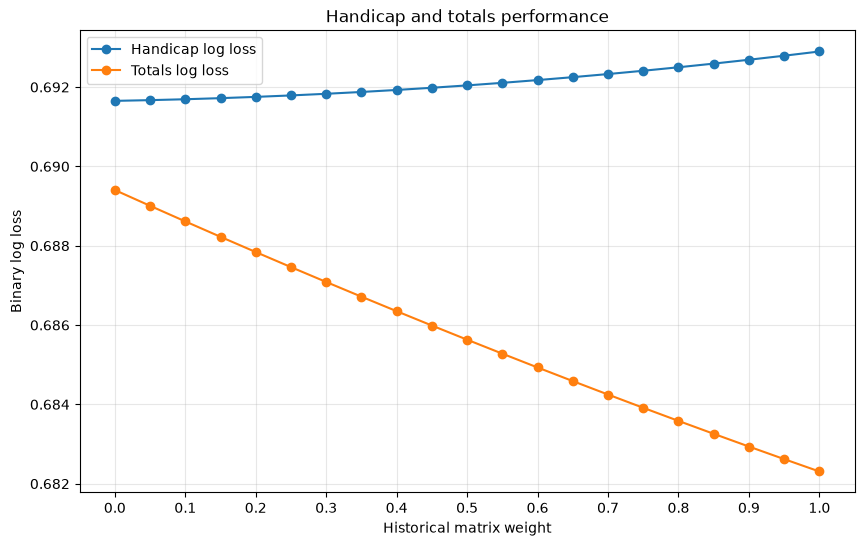

In [49]:
plt.figure(figsize=(10, 6))

plt.plot(
    summary_extended["historical_weight"],
    summary_extended["handicap_log_loss"],
    marker="o",
    label="Handicap log loss",
)

plt.plot(
    summary_extended["historical_weight"],
    summary_extended["totals_log_loss"],
    marker="o",
    label="Totals log loss",
)

plt.xlabel("Historical matrix weight")
plt.ylabel("Binary log loss")
plt.title("Handicap and totals performance")
plt.xticks(np.arange(0.0, 1.01, 0.1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [52]:
example_row = evaluation_matches.iloc[
    len(evaluation_matches) // 2
]

example_prior = matches.loc[
    matches["match_date"] < example_row["match_date"]
]

example_expected_home = float(
    example_row["expected_home_score"]
)

example_expected_away = float(
    example_row["expected_away_score"]
)

example_poisson = poisson_score_matrix(
    example_expected_home,
    example_expected_away,
)

example_empirical = build_historical_matrix(
    example_prior,
    pd.Timestamp(example_row["match_date"]),
)

example_historical = tilt_matrix_to_means(
    example_empirical,
    target_home_mean=example_expected_home,
    target_away_mean=example_expected_away,
)

example_blend = blend_matrices(
    example_poisson,
    example_historical,
    historical_weight_value=0.80,
)

print(
    f"{example_row['home_team']} vs "
    f"{example_row['away_team']}"
)

print(
    "Expected score:",
    round(example_expected_home, 2),
    "-",
    round(example_expected_away, 2),
)

print(
    "Actual score:",
    int(example_row["actual_home_score"]),
    "-",
    int(example_row["actual_away_score"]),
)

Leigh Leopards vs Hull FC
Expected score: 35.45 - 19.23
Actual score: 42 - 12


In [53]:
mean_check = pd.DataFrame(
    [
        {
            "model": "Pure Poisson",
            "home_mean": matrix_means(
                example_poisson
            )[0],
            "away_mean": matrix_means(
                example_poisson
            )[1],
        },
        {
            "model": "Tilted historical",
            "home_mean": matrix_means(
                example_historical
            )[0],
            "away_mean": matrix_means(
                example_historical
            )[1],
        },
        {
            "model": "80% historical blend",
            "home_mean": matrix_means(
                example_blend
            )[0],
            "away_mean": matrix_means(
                example_blend
            )[1],
        },
    ]
)

mean_check["home_target"] = example_expected_home
mean_check["away_target"] = example_expected_away

mean_check.round(8)

,model,home_mean,away_mean,home_target,away_target
0,Pure Poisson,35.450099,19.231915,35.450099,19.231915
1,Tilted historical,35.450100,19.231915,35.450099,19.231915
2,80% historical blend,35.450100,19.231915,35.450099,19.231915


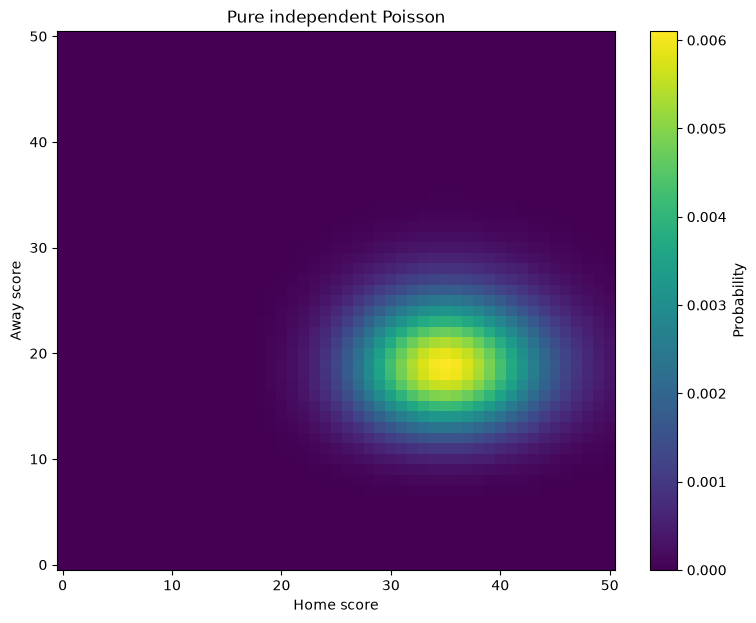

In [55]:
plot_max_score = 50

plt.figure(figsize=(9, 7))

plt.imshow(
    example_poisson[
        : plot_max_score + 1,
        : plot_max_score + 1,
    ].T,
    origin="lower",
    aspect="auto",
)

plt.colorbar(label="Probability")
plt.xlabel("Home score")
plt.ylabel("Away score")
plt.title("Pure independent Poisson")
plt.show()

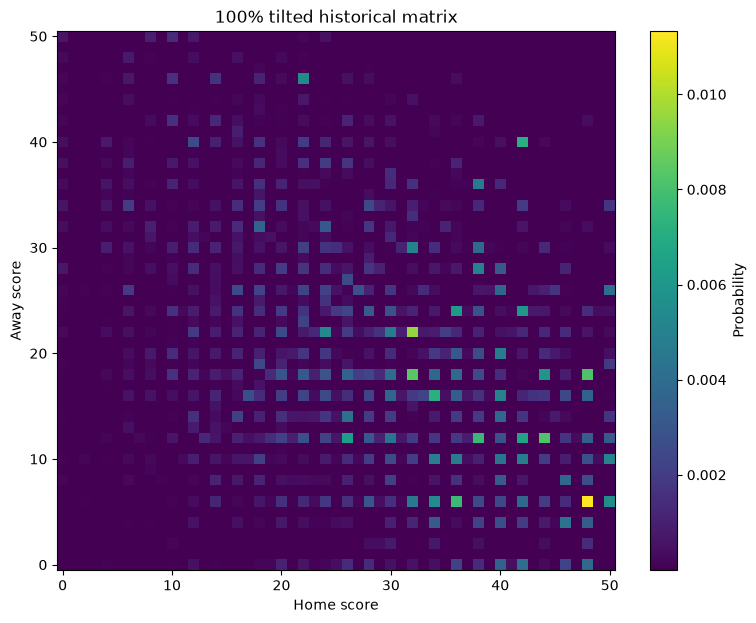

In [56]:
plt.figure(figsize=(9, 7))

plt.imshow(
    example_historical[
        : plot_max_score + 1,
        : plot_max_score + 1,
    ].T,
    origin="lower",
    aspect="auto",
)

plt.colorbar(label="Probability")
plt.xlabel("Home score")
plt.ylabel("Away score")
plt.title("100% tilted historical matrix")
plt.show()

In [57]:
actual_home = min(
    int(example_row["actual_home_score"]),
    MAX_SCORE,
)

actual_away = min(
    int(example_row["actual_away_score"]),
    MAX_SCORE,
)

fixture_probability_comparison = pd.DataFrame(
    [
        {
            "model": "Pure Poisson",
            "actual_score_probability": (
                example_poisson[
                    actual_home,
                    actual_away,
                ]
            ),
        },
        {
            "model": "80% historical blend",
            "actual_score_probability": (
                example_blend[
                    actual_home,
                    actual_away,
                ]
            ),
        },
        {
            "model": "Tilted historical",
            "actual_score_probability": (
                example_historical[
                    actual_home,
                    actual_away,
                ]
            ),
        },
    ]
)

fixture_probability_comparison[
    "exact_score_log_loss"
] = -np.log(
    np.clip(
        fixture_probability_comparison[
            "actual_score_probability"
        ],
        EPSILON,
        None,
    )
)

fixture_probability_comparison

,model,actual_score_probability,exact_score_log_loss
0,Pure Poisson,0.000824,7.100962
1,80% historical blend,0.005462,5.209859
2,Tilted historical,0.006622,5.017361


In [58]:
def decimal_price(probability: float) -> float:
    return 1.0 / probability if probability > 0 else np.inf


fixture_market_comparison = []

for model_name, matrix in [
    ("Pure Poisson", example_poisson),
    ("80% historical blend", example_blend),
    ("Tilted historical", example_historical),
]:
    result_probs = match_result_probabilities(matrix)

    fixture_market_comparison.append(
        {
            "model": model_name,
            "home_win_probability": result_probs["home"],
            "draw_probability": result_probs["draw"],
            "away_win_probability": result_probs["away"],
            "home_win_price": decimal_price(
                result_probs["home"]
            ),
            "draw_price": decimal_price(
                result_probs["draw"]
            ),
            "away_win_price": decimal_price(
                result_probs["away"]
            ),
        }
    )

pd.DataFrame(fixture_market_comparison).round(4)

,model,home_win_probability,draw_probability,away_win_probability,home_win_price,draw_price,away_win_price
0,Pure Poisson,0.9842,0.0047,0.0111,1.0161,211.6017,90.2151
1,80% historical blend,0.7968,0.0055,0.1977,1.2550,181.5300,5.0581
2,Tilted historical,0.7499,0.0057,0.2444,1.3334,175.3018,4.0923


In [59]:
backtest_extended["season"] = (
    backtest_extended["match_date"].dt.year
)

season_summary = (
    backtest_extended
    .groupby(
        ["season", "historical_weight"],
        as_index=False,
    )
    .agg(
        fixtures=("fixture_id", "nunique"),
        exact_score_log_loss=(
            "exact_score_log_loss",
            "mean",
        ),
        result_log_loss=(
            "result_log_loss",
            "mean",
        ),
        result_brier=(
            "result_brier",
            "mean",
        ),
        handicap_log_loss=(
            "handicap_log_loss",
            "mean",
        ),
        totals_log_loss=(
            "totals_log_loss",
            "mean",
        ),
    )
)

season_summary.round(5)

,season,historical_weight,fixtures,exact_score_log_loss,result_log_loss,result_brier,handicap_log_loss,totals_log_loss
0,2022,0.00,55,11.30282,0.79829,0.43810,0.69422,0.69287
1,2022,0.05,55,8.53925,0.74662,0.43334,0.69431,0.69271
2,2022,0.10,55,8.18874,0.71612,0.42896,0.69439,0.69256
3,2022,0.15,55,7.97327,0.69413,0.42495,0.69448,0.69241
4,2022,0.20,55,7.81780,0.67717,0.42132,0.69458,0.69226
...,...,...,...,...,...,...,...,...
100,2026,0.80,151,7.12635,0.61994,0.41896,0.69277,0.68456
101,2026,0.85,151,7.10594,0.61968,0.42006,0.69301,0.68400
102,2026,0.90,151,7.09245,0.61993,0.42159,0.69325,0.68344
103,2026,0.95,151,7.09109,0.62066,0.42353,0.69350,0.68290


In [60]:
best_weight_by_season = (
    season_summary.loc[
        season_summary
        .groupby("season")[
            "exact_score_log_loss"
        ]
        .idxmin()
    ]
    [
        [
            "season",
            "fixtures",
            "historical_weight",
            "exact_score_log_loss",
        ]
    ]
    .sort_values("season")
    .reset_index(drop=True)
)

best_weight_by_season

,season,fixtures,historical_weight,exact_score_log_loss
0,2022,55,0.85,7.174299
1,2023,178,0.90,7.205163
2,2024,178,0.90,7.541929
3,2025,176,0.95,6.951023
4,2026,151,0.95,7.091085


In [61]:
def bootstrap_model_difference(
    data: pd.DataFrame,
    metric: str,
    comparison_weight: float,
    baseline_weight: float = 0.0,
    samples: int = 2_000,
    seed: int = 42,
) -> pd.Series:
    comparison = data.loc[
        data["historical_weight"].isin(
            [baseline_weight, comparison_weight]
        )
    ]

    wide = comparison.pivot(
        index="fixture_id",
        columns="historical_weight",
        values=metric,
    ).dropna()

    differences = (
        wide[comparison_weight].to_numpy()
        - wide[baseline_weight].to_numpy()
    )

    rng = np.random.default_rng(seed)

    bootstrap_means = np.empty(samples)

    for index in range(samples):
        sampled_differences = rng.choice(
            differences,
            size=len(differences),
            replace=True,
        )

        bootstrap_means[index] = (
            sampled_differences.mean()
        )

    return pd.Series(
        {
            "fixtures": len(differences),
            "mean_difference": differences.mean(),
            "lower_95": np.quantile(
                bootstrap_means,
                0.025,
            ),
            "upper_95": np.quantile(
                bootstrap_means,
                0.975,
            ),
            "probability_comparison_is_better": (
                bootstrap_means < 0
            ).mean(),
        }
    )

In [62]:
bootstrap_comparisons = []

comparison_settings = [
    ("Pure historical", 1.00),
    ("80% historical", 0.80),
    ("70% historical", 0.70),
]

for label, weight in comparison_settings:
    for metric in [
        "exact_score_log_loss",
        "result_log_loss",
        "result_brier",
        "handicap_log_loss",
        "totals_log_loss",
    ]:
        result = bootstrap_model_difference(
            backtest_extended,
            metric=metric,
            comparison_weight=weight,
        )

        bootstrap_comparisons.append(
            {
                "comparison": label,
                "historical_weight": weight,
                "metric": metric,
                **result.to_dict(),
            }
        )

bootstrap_results = pd.DataFrame(
    bootstrap_comparisons
)

bootstrap_results.round(6)

,comparison,historical_weight,metric,fixtures,mean_difference,lower_95,upper_95,probability_comparison_is_better
0,Pure historical,1.0,exact_score_log_loss,738.0,-4.538096,-4.999630,-4.065822,1.0000
1,Pure historical,1.0,result_log_loss,738.0,-0.178866,-0.247398,-0.111583,1.0000
2,Pure historical,1.0,result_brier,738.0,-0.027070,-0.051842,-0.003110,0.9865
3,Pure historical,1.0,handicap_log_loss,738.0,0.001245,-0.001869,0.004322,0.2345
4,Pure historical,1.0,totals_log_loss,738.0,-0.007096,-0.009979,-0.004135,1.0000
5,80% historical,0.8,exact_score_log_loss,738.0,-4.800506,-5.213336,-4.396318,1.0000
6,80% historical,0.8,result_log_loss,738.0,-0.184195,-0.247911,-0.122483,1.0000
7,80% historical,0.8,result_brier,738.0,-0.034393,-0.054170,-0.015285,0.9995
8,80% historical,0.8,handicap_log_loss,738.0,0.000847,-0.001647,0.003318,0.2760
9,80% historical,0.8,totals_log_loss,738.0,-0.005821,-0.008129,-0.003448,1.0000


In [64]:
weights_to_compare = [0.00, 0.70, 0.80, 1.00]

final_comparison = (
    summary_extended.loc[
        summary_extended[
            "historical_weight"
        ].isin(weights_to_compare)
    ]
    .copy()
    .reset_index(drop=True)
)

final_comparison.round(6)

,historical_weight,model,fixtures,exact_score_log_loss,result_log_loss,result_brier,handicap_log_loss,totals_log_loss,home_mean_abs_error,away_mean_abs_error
0,0.0,pure_poisson,738,12.037936,0.793254,0.437075,0.691652,0.689403,0.0,0.0
1,0.7,blend_0.70,738,7.296942,0.609705,0.401408,0.692328,0.684247,0.0,0.0
2,0.8,blend_0.80,738,7.237430,0.609059,0.402682,0.692499,0.683583,0.0,0.0
3,1.0,tilted_historical,738,7.499840,0.614388,0.410005,0.692896,0.682307,0.0,0.0
